# Overleaf Figures
Figures for the master thesis paper.

In [7]:
import random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import Normalize

from utils.mri.data_loader import DataLoader
from utils.mri.data_converter import DataConverter

root_path      = 'data/'
random_seed    = 42
# Crop margins used during training: removes noisy/empty borders
CROP = ((16, 10, 0), (17, 11, 17))

data_loader    = DataLoader(root_path=root_path)
data_converter = DataConverter()

FIG_DIR = 'out/overleaf_figures'
import os
os.makedirs(FIG_DIR, exist_ok=True)

def load_cropped_slice(path, slice=None):
    """Load NIfTI, apply training crop, return axial middle slice (H x W)."""
    vol = data_converter.load_path_as_numpy(path)   # (D, H, W)
    d0, h0, w0 = CROP[0]
    d1, h1, w1 = CROP[1]
    D, H, W = vol.shape
    vol = vol[d0:D-d1, h0:H-h1, w0:W-w1]
    if slice is None: slice = vol.shape[2] // 2
    return vol[:, :, slice]

random.seed(random_seed)
print('Imports OK')

Imports OK


---
## Background

### Figure 1 — Cropped HUNT brain with tissue legend
Shows WM (~1.0), GM (~0.8) and CSF (~0) intensity levels.

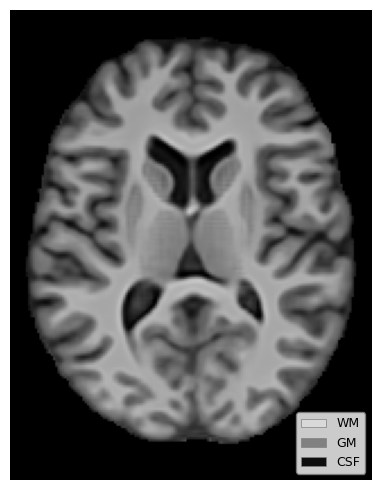

In [15]:
random.seed(random_seed)
h3_path, _ = data_loader.get_random_pair_path()
slice1 = load_cropped_slice(h3_path)

fig, ax = plt.subplots(figsize=(5, 5))
ax.imshow(slice1.T, cmap='gray', vmin=0, vmax=1, origin='lower')
ax.axis('off')

# Build a legend with three intensity swatches
wm_patch  = mpatches.Patch(facecolor=str(0.85),  edgecolor='gray', linewidth=0.5, label='WM')
gm_patch  = mpatches.Patch(facecolor=str(0.5),  edgecolor='gray', linewidth=0.5, label='GM')
csf_patch = mpatches.Patch(facecolor=str(0.05), edgecolor='gray', linewidth=0.5, label='CSF')

ax.legend(
    handles=[wm_patch, gm_patch, csf_patch],
    loc='lower right',
    fontsize=9,
    edgecolor='gray',
)

plt.tight_layout()
plt.savefig(f'{FIG_DIR}/bg_tissue_legend.png', bbox_inches='tight', dpi=300)
plt.show()

### Figure 2 — Cropped HUNT brain (no legend) for lateral ventricle illustration

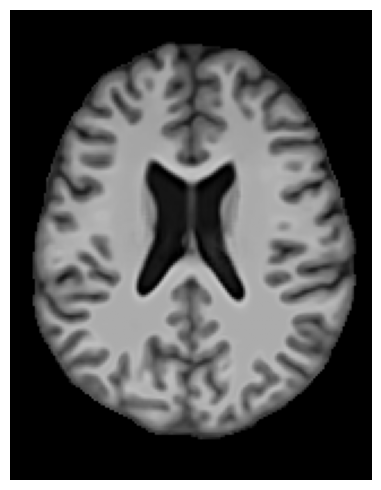

In [9]:
# Pick a different subject to avoid repeating the same brain
all_pairs = data_loader.get_all_pair_paths()
random.seed(random_seed + 7)
h3_path2, _ = random.choice(all_pairs)
slice2 = load_cropped_slice(h3_path2, 100)

fig, ax = plt.subplots(figsize=(5, 5))
ax.imshow(slice2.T, cmap='gray', vmin=0, vmax=1, origin='lower')
ax.axis('off')

plt.tight_layout()
plt.savefig(f'{FIG_DIR}/bg_lateral_ventricles.png', bbox_inches='tight', dpi=300)
plt.show()

### Figure 3 — HUNT3 / HUNT4 pair and absolute difference
Shows longitudinal change between the two timepoints.

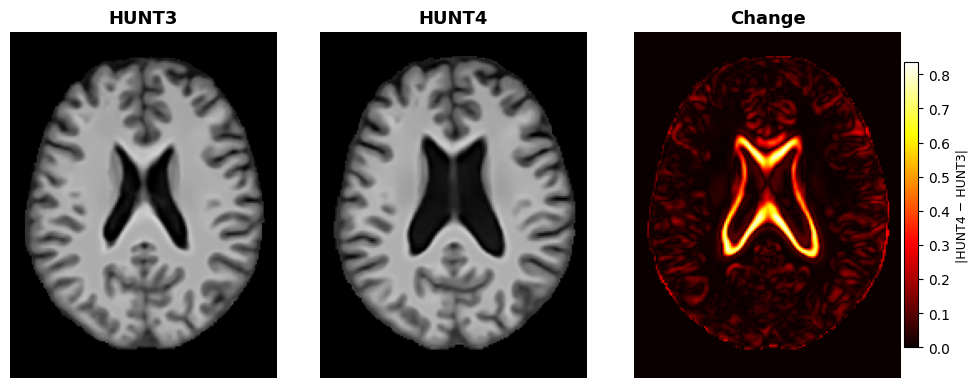

In [10]:
random.seed(random_seed + 13)
h3_path3, h4_path3 = random.choice(all_pairs)
slice_h3 = load_cropped_slice(h3_path3, 100)
slice_h4 = load_cropped_slice(h4_path3, 100)
slice_diff = np.abs(slice_h4 - slice_h3)

fig, axes = plt.subplots(1, 3, figsize=(12, 4.5), gridspec_kw={'wspace': 0})

titles = ['HUNT3', 'HUNT4', 'Change']
slices = [slice_h3, slice_h4, slice_diff]
cmaps  = ['gray', 'gray', 'hot']
vmaxes = [1.0, 1.0, slice_diff.max() or 0.3]

for ax, title, sl, cmap, vmax in zip(axes, titles, slices, cmaps, vmaxes):
    im = ax.imshow(sl.T, cmap=cmap, vmin=0, vmax=vmax, origin='lower')
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.axis('off')
    if cmap == 'hot':
        cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.01)
        cbar.set_label('|HUNT4 − HUNT3|', fontsize=9)

plt.savefig(f'{FIG_DIR}/bg_hunt34_pair_diff.png', bbox_inches='tight', dpi=300)
plt.show()

---
## Methodology

In [11]:
# Methodology figures go here

---
## Results

In [12]:
# Results figures go here